In [17]:
df = pd.read_csv(r'D:\Python\Project59\ML_Workshop_Customer360\data\customer_360_ml_workshop.csv')

In [18]:
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [19]:
df = pd.read_csv(r'D:\Python\Project59\ML_Workshop_Customer360\data\customer_360_ml_workshop.csv')
display(df.head())

,CustomerID,Age,Region,TenureMonths,ContractType,InternetType,MonthlyUsageGB,MonthlyChargeEGP,NumServices,SupportCalls6M,LatePayments12M,PaperlessBilling,AutoPay,SatisfactionScore,Future12MRevenueEGP,Churn
0,CUST-00001,22,Alexandria,23,Month-to-month,DSL,317.9,580.48,5,5,0,Yes,Yes,5.0,6287.08,Yes
1,CUST-00002,59,Upper Egypt,9,Month-to-month,4G/5G,359.3,434.36,1,1,1,No,Yes,4.0,4619.91,No
2,CUST-00003,52,Giza,21,Month-to-month,DSL,176.9,391.35,3,5,1,Yes,Yes,5.0,4512.25,No
3,CUST-00004,41,Giza,12,Month-to-month,DSL,312.5,420.40,3,2,1,No,Yes,5.0,3809.65,No
4,CUST-00005,40,Delta,21,Month-to-month,4G/5G,191.6,462.73,3,4,0,No,Yes,3.0,4731.09,No


In [20]:
models = {
    'Linear Regression': LinearRegression(),
    
    'Ridge': Ridge(alpha=1.0),
    
    'Lasso': Lasso(alpha=0.1, max_iter=10000),
    
    'KNN Regressor': KNeighborsRegressor(n_neighbors=5),
    
    'Decision Tree': DecisionTreeRegressor(
        random_state=42
    ),
    
    'Random Forest': RandomForestRegressor(
        n_estimators=100,
        random_state=42,
        n_jobs=-1
    ),
    
    'Gradient Boosting': GradientBoostingRegressor(
        random_state=42
    )
}

In [22]:
# Features and target for Revenue Regression
X_reg = df.drop(
    columns=["CustomerID", "Future12MRevenueEGP", "Churn"]
)

y_reg = df["Future12MRevenueEGP"]

# Train-test split
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_reg,
    y_reg,
    test_size=0.2,
    random_state=42
)

In [23]:
results = []
trained_models = {}

for name, model in models.items():

    pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('model', model)
    ])

    pipeline.fit(X_train_reg, y_train_reg)

    y_pred = pipeline.predict(X_test_reg)

    mae = mean_absolute_error(y_test_reg, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test_reg, y_pred))
    r2 = r2_score(y_test_reg, y_pred)

    results.append({
        'Model': name,
        'MAE': mae,
        'RMSE': rmse,
        'R²': r2
    })

    trained_models[name] = pipeline

results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    by='RMSE',
    ascending=True
)

display(results_df)

,Model,MAE,RMSE,R²
6,Gradient Boosting,368.560228,464.972316,0.896807
1,Ridge,378.416604,474.914752,0.892347
0,Linear Regression,378.426990,474.928058,0.892341
2,Lasso,378.451636,474.942086,0.892335
5,Random Forest,393.554831,496.139312,0.882510
4,Decision Tree,537.060217,683.953597,0.776721
3,KNN Regressor,619.291123,783.499159,0.706998


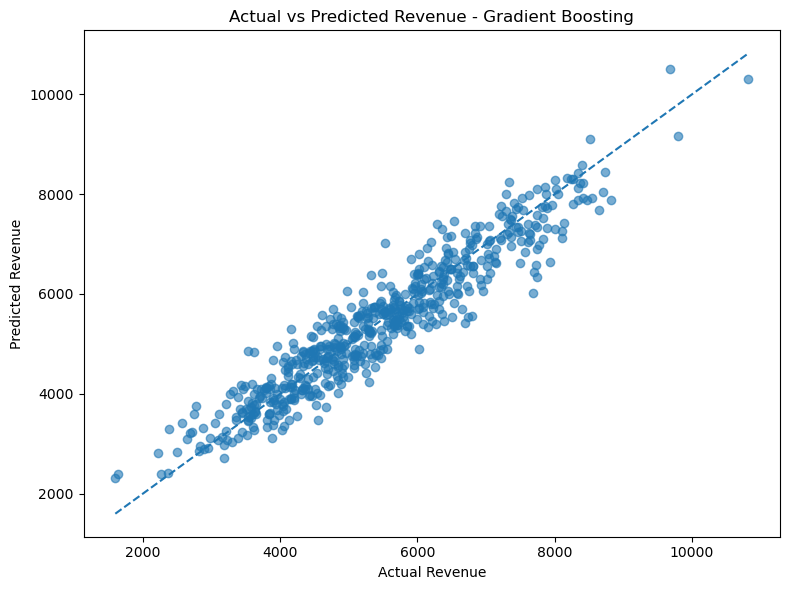

In [25]:
# Best model based on RMSE
best_model_name = results_df.iloc[0]["Model"]
best_model = trained_models[best_model_name]

# Predict revenue
y_pred_best = best_model.predict(X_test_reg)

# Actual vs Predicted Revenue
plt.figure(figsize=(8, 6))

plt.scatter(
    y_test_reg,
    y_pred_best,
    alpha=0.6
)

# Perfect prediction line
min_value = min(y_test_reg.min(), y_pred_best.min())
max_value = max(y_test_reg.max(), y_pred_best.max())

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle="--"
)

plt.xlabel("Actual Revenue")
plt.ylabel("Predicted Revenue")
plt.title(f"Actual vs Predicted Revenue - {best_model_name}")

plt.tight_layout()
plt.show()

##### The predicted values closely follow the ideal diagonal, showing that Gradient Boosting predicts future revenue accurately across the range of customers. The largest errors occur for the highest-revenue customers, who are slightly under-predicted.


### Part D — Revenue Regression Summary

The seven regression models were evaluated using **MAE, RMSE, and R²** to predict `Future12MRevenueEGP`.

* **Gradient Boosting** achieved the strongest overall results, with the **lowest MAE (368.56)** and **lowest RMSE (464.97)**, while also achieving the **highest R² (0.897)**.
* **Ridge, Linear Regression, and Lasso** performed very similarly, with R² values around **0.892**. This indicates that the relationship between the features and future revenue is largely captured by a linear model.
* **Random Forest** also performed well, achieving an R² of **0.883**, but it was slightly less accurate than the linear models and Gradient Boosting.
* **Decision Tree** and **KNN Regressor** had noticeably higher errors and lower R² values, indicating weaker predictive performance on this dataset.

**Overall, Gradient Boosting provided the best predictive performance among the tested models**, explaining approximately **89.7% of the variation in future 12-month revenue**.
